# ARIMA

This notebook demonstrates the **ARIMA** forecaster in the `aeon` toolkit. ARIMA — AutoRegressive Integrated Moving Average — is the other great classical family of forecasters alongside exponential smoothing ([ETS](ets.ipynb)). Instead of smoothing a level, it models a series as a linear regression on (a) its own recent values and (b) its own recent forecast errors, after differencing the series to make it stationary.

ETS and ARIMA overlap more than they look: several ETS models have exact ARIMA equivalents (see section 6). The state-space formulation and the automatic-selection algorithm used here follow Hyndman and Athanasopoulos.

> R. J. Hyndman & G. Athanasopoulos (2021). *Forecasting: Principles and Practice* (3rd ed.), OTexts. https://otexts.com/fpp3/


## 1. How the ARIMA algorithm works

ARIMA has three orders, written **ARIMA(p, d, q)**:

- **AR(p)** — *autoregression*: regress the current value on its previous $p$ values, with coefficients $\phi_1, \dots, \phi_p$. This captures momentum/persistence.
- **I(d)** — *integration*: difference the series $d$ times ($w_t = \Delta^d y_t$) so that the result is **stationary** (no trend). Forecasts are made on $w_t$ and then "un-differenced" back to the original scale.
- **MA(q)** — *moving average*: regress on the previous $q$ forecast **errors** $\varepsilon_{t-1}, \dots, \varepsilon_{t-q}$, with coefficients $\theta_1, \dots, \theta_q$. This lets the model react to recent shocks.

On the differenced series the one-step model is just a linear combination:

$$\hat{w}_t = c + \sum_{i=1}^{p} \phi_i\, w_{t-i} + \sum_{j=1}^{q} \theta_j\, \varepsilon_{t-j}, \qquad \varepsilon_t = w_t - \hat{w}_t.$$

The optional constant $c$ matters: with $d = 1$ a non-zero $c$ is a **drift** term, so ARIMA(0,1,0) with a constant is exactly a *random walk with drift*. The coefficients $\phi$, $\theta$ and $c$ are estimated by a Nelder-Mead search that minimises the AIC.

Multi-step forecasts are recursive: future values feed the AR part, while future errors are unknown and set to zero, so the MA part only contributes for the first $q$ steps.


## 2. Parameters and their effects

- **`p`** (default `1`): AR order — how many past values to regress on.
- **`d`** (default `0`): differencing order — how many times to difference for stationarity. `d=1` removes a linear trend, `d=2` a quadratic one.
- **`q`** (default `1`): MA order — how many past errors to use.
- **`use_constant`** (default `False`): include the intercept $c$. With `d=1` this becomes a drift term.
- **`iterations`** (default `200`): Nelder-Mead budget.

After fitting, the coefficients are exposed as `phi_` (length `p`), `theta_` (length `q`), `c_` (the constant) and `aic_`. ARIMA also supports **exogenous variables** (`exog`): it fits an OLS regression of `y` on the exog and models the residuals as ARIMA.

Choosing `(p, d, q)` by hand needs care, so in practice **`AutoARIMA`** selects them for you (section 5).


## 3. Forecasting with ARIMA

### Imports


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from aeon.datasets import load_airline
from aeon.forecasting.stats import ARIMA, AutoARIMA
from aeon.forecasting.utils._hypo_tests import kpss_test

### Example: fit, `forecast` and `iterative_forecast`

We use the same trending series as the [ETS](ets.ipynb) and [CES](ces.ipynb) notebooks and hold out the last 12 points. A trend is non-stationary, so we difference once (`d=1`) and include a constant — i.e. an ARIMA(1,1,1) with drift.


One-step-ahead forecast: 33.266


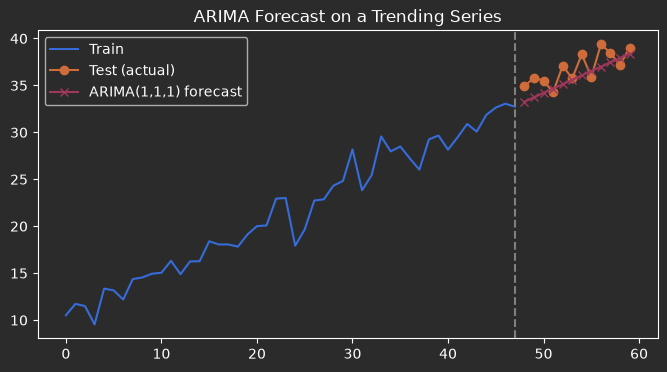

Test MSE over 12 steps: 2.163


In [2]:
# A trending series + noise (same as the ETS / CES notebooks)
rng = np.random.default_rng(1)
n_points = 60
time = np.arange(n_points)
y = 10 + 0.5 * time + rng.normal(scale=1.5, size=n_points)

y_train, y_test = y[:-12], y[-12:]

forecaster = ARIMA(p=1, d=1, q=1, use_constant=True)
forecaster.fit(y_train)
print(f"One-step-ahead forecast: {forecaster.forecast(y_train):.3f}")

y_preds = forecaster.iterative_forecast(y_train, prediction_horizon=len(y_test))

test_time = np.arange(len(y_train), len(y))
plt.figure(figsize=(8, 4))
plt.plot(np.arange(len(y_train)), y_train, label="Train")
plt.plot(test_time, y_test, marker="o", label="Test (actual)")
plt.plot(test_time, y_preds, marker="x", label="ARIMA(1,1,1) forecast")
plt.axvline(x=len(y_train) - 1, linestyle="--", color="grey")
plt.legend()
plt.title("ARIMA Forecast on a Trending Series")
plt.show()

print(f"Test MSE over {len(y_test)} steps: " f"{np.mean((y_test - y_preds) ** 2):.3f}")

Look at the fitted coefficients. The constant on the differenced series is a **drift** that recovers the underlying slope of about 0.5:


In [3]:
print(f"phi_ (AR): {np.round(forecaster.phi_, 4)}")
print(f"theta_ (MA): {np.round(forecaster.theta_, 4)}")
print(f"c_ (drift on differenced series): {forecaster.c_:.4f}")
print(f"aic_: {forecaster.aic_:.2f}")

phi_ (AR): [0.0833]
theta_ (MA): [-0.9466]
c_ (drift on differenced series): 0.4264
aic_: 171.30


## 4. Worked example: the recursive forecast

ARIMA's multi-step forecast is a recursion on the **differenced** series, followed by un-differencing. We reproduce `iterative_forecast` by hand to see exactly how the pieces fit:

1. difference the training series to get $w = \Delta y$;
2. at each future step, predict $\hat{w} = c + \phi\, w_{t-1} + \theta\, \varepsilon_{t-1}$, feeding the prediction back in for the AR term and using **zero** for unknown future errors;
3. un-difference by a cumulative sum from the last observed value.


In [4]:
phi, theta, c = forecaster.phi_, forecaster.theta_, forecaster.c_
h = len(y_test)

w = np.diff(y_train)  # differenced series (d=1)
resid = np.asarray(forecaster.residuals_)
n = len(w)

w_path = np.concatenate([w, np.zeros(h)])
err = np.concatenate([resid, np.zeros(h)])  # future errors are 0
for i in range(h):
    tpos = n + i
    ar = phi[0] * w_path[tpos - 1]
    ma = theta[0] * err[tpos - 1]
    w_path[tpos] = c + ar + ma

w_forecast = w_path[n : n + h]
manual = y_train[-1] + np.cumsum(w_forecast)  # un-difference (d=1)

print("Max abs diff vs iterative_forecast:", np.max(np.abs(manual - y_preds)))

Max abs diff vs iterative_forecast: 7.105427357601002e-15


Exact match. Two things are worth noticing from this recursion:

- After the first step the MA term contributes nothing (future errors are zero), so beyond lag $q$ the forecast is driven entirely by the AR part plus the drift $c$. That is why the long-run forecast of an ARIMA(1,1,1) with drift settles into a straight line of slope $\approx c$.
- The un-differencing (cumulative sum) is what turns a forecast of *changes* back into a forecast of *levels*.


## 5. Differencing, stationarity and AutoARIMA

The "I" in ARIMA is about **stationarity**: AR and MA terms assume the series has no trend. `AutoARIMA` uses the **Hyndman-Khandakar** algorithm — it first runs a **KPSS test** repeatedly, differencing until the series is judged stationary (that fixes `d`), then does a stepwise search over `p` and `q` minimising AIC.

We can watch the KPSS test drive the choice of `d` on the airline series:


In [5]:
y_air = load_airline().squeeze()
y_train, y_test = y_air[:-24], y_air[-24:]

series = y_train.copy()
for d in range(3):
    stat, stationary = kpss_test(series)[0], kpss_test(series)[1]
    print(f"d={d}: KPSS stat={stat:.3f}  stationary={stationary}")
    series = np.diff(series)

d=0: KPSS stat=1.164  stationary=False
d=1: KPSS stat=0.130  stationary=True
d=2: KPSS stat=0.072  stationary=True


AutoARIMA selected ARIMA(p=1, d=1, q=2), constant=True
AutoARIMA test MSE: 9648.7


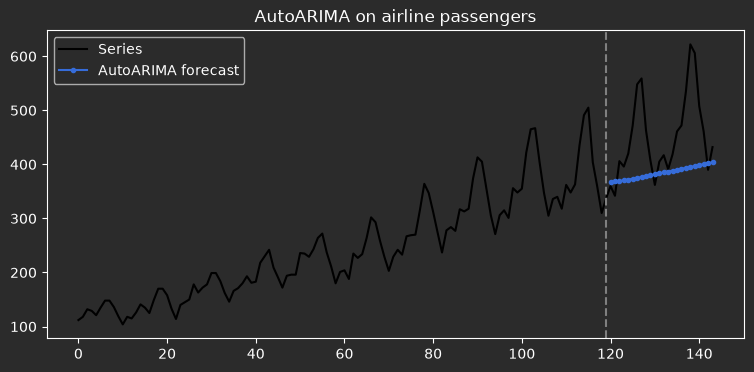

In [6]:
auto = AutoARIMA()
auto.fit(y_train)
print(
    f"AutoARIMA selected ARIMA(p={auto.p_}, d={auto.d_}, q={auto.q_}), "
    f"constant={auto.constant_term_}"
)

auto_preds = auto.iterative_forecast(y_train, prediction_horizon=24)
print(f"AutoARIMA test MSE: {np.mean((y_test - auto_preds) ** 2):.1f}")

tt = np.arange(len(y_air))
plt.figure(figsize=(9, 4))
plt.plot(tt, y_air, label="Series", color="black")
plt.axvline(x=len(y_train) - 1, linestyle="--", color="grey")
fut = np.arange(len(y_train), len(y_air))
plt.plot(fut, auto_preds, marker=".", label="AutoARIMA forecast")
plt.legend()
plt.title("AutoARIMA on airline passengers")
plt.show()

Notice the forecast captures the upward **trend** but flattens through the seasonal peaks and troughs. This implementation is **non-seasonal** ARIMA: it has no seasonal (P, D, Q) orders, so it cannot reproduce the 12-month cycle, only the trend left after differencing. For strongly seasonal data like this, a seasonal model — the seasonal variants of [CES](ces.ipynb) or [ETS](ets.ipynb), or a seasonal ARIMA — will do much better. This is the honest counterpart to the seasonal sections of those notebooks: matching the model to the seasonal structure of the data matters more than the choice of family.


## 6. How ARIMA relates to ETS and the rest

ARIMA and ETS are the two classical pillars, and they overlap. Some **linear ETS models are exactly equivalent to ARIMA models**:

| ETS model | Equivalent ARIMA |
|---|---|
| `ETS(A,N,N)` (simple exp. smoothing) | ARIMA(0,1,1) |
| `ETS(A,A,N)` (Holt's linear trend) | ARIMA(0,2,2) |
| `ETS(A,Ad,N)` (damped trend) | ARIMA(1,1,2) |
| random walk with drift | ARIMA(0,1,0) + constant |

The difference is the modelling philosophy. **ETS** ([notebook](ets.ipynb)) builds a series up from interpretable level/trend/season components; **ARIMA** describes the series through correlations with its own past (AR) and past shocks (MA) once made stationary (I). **CES** ([notebook](ces.ipynb)) is a third route that absorbs the structure into a complex smoothing parameter, and **Theta**/[DOTM](dotm.ipynb) are lightweight trend-plus-smoothing special cases. In practice you rarely pick by hand — `AutoARIMA`, `AutoETS` and `AutoCES` each search their own family by information criterion, and comparing their outputs is a good default workflow.


## 7. Summary

- **ARIMA(p, d, q)** models a series via autoregression (AR), differencing for stationarity (I), and a moving average of past errors (MA).
- The fit estimates `phi_`, `theta_` and an optional constant `c_` (a **drift** when `d=1`) by minimising AIC; forecasts are made on the differenced series and un-differenced back.
- **`AutoARIMA`** picks `d` via repeated KPSS stationarity tests, then searches `p` and `q` by AIC (Hyndman-Khandakar).
- This is a **non-seasonal** ARIMA: it captures trend but not seasonal cycles — use a seasonal model for seasonal data.
- ARIMA and **[ETS](ets.ipynb)** are closely related; several ETS models have exact ARIMA equivalents (section 6).

### Reference

R. J. Hyndman & G. Athanasopoulos (2021). *Forecasting: Principles and Practice* (3rd ed.), OTexts.
